In [1]:
import numpy as np
import numba as nb
import math
from time import perf_counter
import matplotlib.pyplot as plt

from gridcp import (
    OnlineChangepointDetector,
    make_univariate_mean_change_detector,
    make_univariate_variance_change_detector,
    make_univariate_mean_or_variance_change_detector,
    make_multivariate_mean_change_detector,
    make_multivariate_mean_or_covariance_change_detector,
    make_regression_change_detector,
)
from gridcp.utils import fastlog
from gridcp.calibration import draw_samples, mc_max_statistics
from gridcp import builtins
from gridcp.builtins import gen_gaussian_regression_obs

# Some examples with simulations below

In [5]:
N = 100_000  # stream length
K_calibrate = 10  # number of MC samples for threshold calibration

detector = make_univariate_mean_change_detector()
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)

In [6]:
N = 50  # stream length
K_calibrate = 10000  # number of MC samples for threshold calibration
K = 1000  # number of MC samples for performance evaluation
changepoint_loc = N // 2

## Univariate change-in-mean

In [7]:
p = 1

### Known variance

In [8]:
detector = make_univariate_mean_change_detector()


detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_known_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_known_var)

critical value =  2.9627207432949887


In [5]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 2, "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_mean_change_detector(
        penalty_constant=critical_value_known_var
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 4.337


### Uknown variance

In [6]:
detector = make_univariate_mean_change_detector(mode="unknown_variance")
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_unknown_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_unknown_var)

critical value =  2.435296875811082


In [7]:
changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 2, "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_mean_change_detector(
        penalty_constant=critical_value_unknown_var, mode="unknown_variance"
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 5.754999999999999


### Change in mean or variance

In [10]:
detector = make_univariate_mean_or_variance_change_detector()
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_meanvariance = detector._state["penalty_constant"]
print("critical value = ", critical_value_meanvariance)

critical value =  3.538391071737553


In [11]:
changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 2, "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_mean_or_variance_change_detector(
        penalty_constant=critical_value_meanvariance
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection time: {np.mean(detect_times) - changepoint_loc}")

Average detection time: 10.468000000000004


In [9]:
mus = np.linspace(0, 3, 10)

changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal

dd1 = np.ones((len(mus), K)) * N
dd2 = np.ones((len(mus), K)) * N
dd3 = np.ones((len(mus), K)) * N


for j in range(len(mus)):
    prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
    postchange_kwargs = {"loc": mus[j], "scale": 1, "size": (p,)}
    xs = draw_samples(
        K=K,
        N=N,
        p=p,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_univariate_mean_change_detector(
            penalty_constant=critical_value_known_var
        )
        detector2 = make_univariate_mean_change_detector(
            penalty_constant=critical_value_unknown_var,
            mode="unknown_variance",
        )
        detector3 = make_univariate_mean_or_variance_change_detector(
            penalty_constant=critical_value_meanvariance
        )
        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector3.update(x_new)
            if detector3.alarm:
                dd3[j, k] = i + 1
                break

NameError: name 'critical_value_unknown_var' is not defined

In [11]:
print("FA 1:", np.mean(dd1[0] < N))
print("FA 2:", np.mean(dd2[0] < N))
print("FA 3:", np.mean(dd3[0] < N))

FA 1: 0.049
FA 2: 0.054
FA 3: 0.052


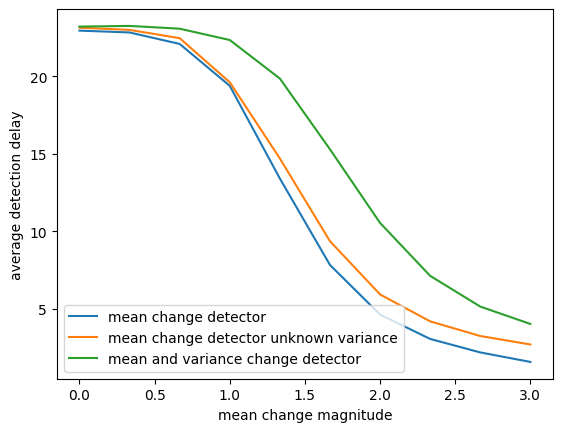

In [12]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc
avg_dd3 = np.mean(dd3, axis=1) - changepoint_loc

plt.plot(mus, avg_dd1, label="mean change detector")
plt.plot(mus, avg_dd2, label="mean change detector unknown variance")
plt.plot(mus, avg_dd3, label="mean and variance change detector")
plt.xlabel("mean change magnitude")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

## Univariate change in variance

### Known mean

In [13]:
detector = make_univariate_variance_change_detector()
detector.calibrate_false_alarm(
    alpha=0.05, N=N, K=K_calibrate, null_dist=np.random.normal
)
critical_value_known_mean = detector._state["penalty_constant"]

In [14]:
changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 0, "scale": 4, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_univariate_variance_change_detector(
        penalty_constant=critical_value_known_mean
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection time: {np.mean(detect_times) - changepoint_loc}")

Average detection time: 4.882999999999999


In [15]:
K = 1000
postchangesds = np.linspace(1, 5, 10)


changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal

dd1 = np.ones((len(postchangesds), K)) * N
dd2 = np.ones((len(postchangesds), K)) * N


for j in range(len(postchangesds)):
    prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
    postchange_kwargs = {"loc": 0, "scale": postchangesds[j], "size": (p,)}
    xs = draw_samples(
        K=K,
        N=N,
        p=p,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_univariate_variance_change_detector(
            penalty_constant=critical_value_known_mean
        )
        detector2 = make_univariate_mean_or_variance_change_detector(
            penalty_constant=critical_value_meanvariance
        )
        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break

In [16]:
print("FA 1:", np.mean(dd1[0] < N))
print("FA 2:", np.mean(dd2[0] < N))

FA 1: 0.054
FA 2: 0.052


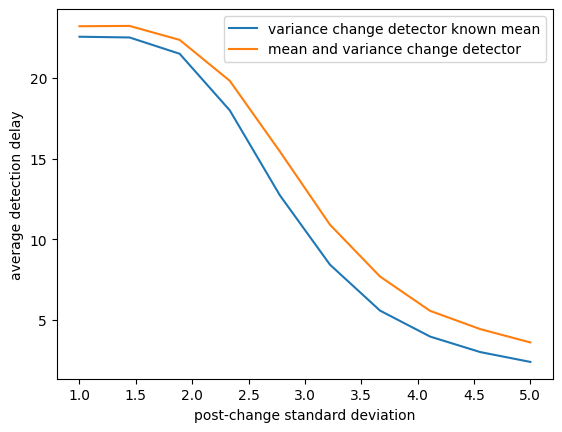

In [17]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc

plt.plot(postchangesds, avg_dd1, label="variance change detector known mean")
plt.plot(postchangesds, avg_dd2, label="mean and variance change detector")
plt.xlabel("post-change standard deviation")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

## Multivariate change in mean

In [18]:
p = 10
N = 50  # stream length
K_calibrate = 10000  # number of MC samples for threshold calibration
K = 1000  # number of MC samples for performance evaluation
changepoint_loc = N // 2

### Known variance (identity)

In [19]:
detector = make_multivariate_mean_change_detector(p=p)
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0, "scale": 1, "size": (p,)},
)
critical_value_multivariate_known_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_multivariate_known_var)

critical value =  3.2426766089345445


In [20]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 3 / math.sqrt(p), "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_multivariate_mean_change_detector(
        p=p, penalty_constant=critical_value_multivariate_known_var
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 2.8810000000000002


### Uknown variance

In [21]:
detector = make_multivariate_mean_change_detector(p=p, mode="unknown_variance")
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0, "scale": 1, "size": (p,)},
)
critical_value_multivariate_unknown_var = detector._state["penalty_constant"]
print("critical value = ", critical_value_multivariate_unknown_var)

critical value =  2.5163534066256585


In [22]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 3 / math.sqrt(p), "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_multivariate_mean_change_detector(
        p=p,
        penalty_constant=critical_value_multivariate_unknown_var,
        mode="unknown_variance",
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc}")

Average detection delay: 8.354999999999997


### Change in mean or variance

In [23]:
detector = make_multivariate_mean_or_covariance_change_detector(p=p)
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0, "scale": 1, "size": (p,)},
)
critical_value_multivariate_meanvariance = detector._state["penalty_constant"]
print("critical value = ", critical_value_meanvariance)

critical value =  3.538391071737553


In [24]:
prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
postchange_kwargs = {"loc": 3 / math.sqrt(p), "scale": 1, "size": (p,)}
xs = draw_samples(
    K=K,
    N=N,
    p=p,
    seed=123,
    pre_change_dist=prechange_dist,
    pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist,
    post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    detector = make_multivariate_mean_or_covariance_change_detector(
        p=p, penalty_constant=critical_value_multivariate_meanvariance
    )
    for i in range(N):
        x_new = xs[k, i]
        detector.update(x_new)
        if detector.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection time: {np.mean(detect_times) - changepoint_loc}")

Average detection time: 21.247999999999998


In [25]:
phis = np.linspace(0, 6, 10)

changepoint_loc = N // 2
prechange_dist = np.random.normal
postchange_dist = np.random.normal

dd1 = np.ones((len(phis), K)) * N
dd2 = np.ones((len(phis), K)) * N
dd3 = np.ones((len(phis), K)) * N


for j in range(len(phis)):
    prechange_kwargs = {"loc": 0, "scale": 1, "size": (p,)}
    postchange_kwargs = {"loc": phis[j] / math.sqrt(p), "scale": 1, "size": (p,)}
    xs = draw_samples(
        K=K,
        N=N,
        p=p,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_multivariate_mean_change_detector(
            p=p, penalty_constant=critical_value_multivariate_known_var
        )
        detector2 = make_multivariate_mean_change_detector(
            p=p,
            penalty_constant=critical_value_multivariate_unknown_var,
            mode="unknown_variance",
        )
        detector3 = make_multivariate_mean_or_covariance_change_detector(
            p=p, penalty_constant=critical_value_multivariate_meanvariance
        )
        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector3.update(x_new)
            if detector3.alarm:
                dd3[j, k] = i + 1
                break

In [26]:
print("FA 1:", np.mean(dd1[0] < N))
print("FA 2:", np.mean(dd2[0] < N))
print("FA 3:", np.mean(dd3[0] < N))

FA 1: 0.055
FA 2: 0.039
FA 3: 0.052


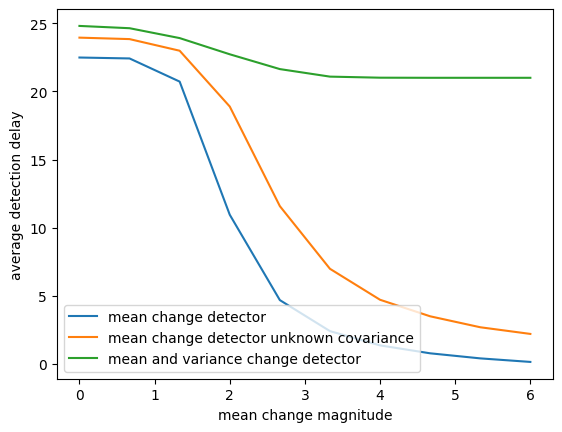

In [27]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc
avg_dd3 = np.mean(dd3, axis=1) - changepoint_loc

plt.plot(phis, avg_dd1, label="mean change detector")
plt.plot(phis, avg_dd2, label="mean change detector unknown covariance")
plt.plot(phis, avg_dd3, label="mean and variance change detector")
plt.xlabel("mean change magnitude")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

# Change in regression coefficients

### McScan

In [6]:
N = 200
q = 10
K_calibrate = 1000
K = 1000
beta0 = np.random.normal(loc=0, scale=1, size=(q,))

detector = make_regression_change_detector(q=q)
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=gen_gaussian_regression_obs,
    null_kwargs={"beta0": beta0},
)
critical_value_reg = detector._state["penalty_constant"]
print("critical value = ", critical_value_reg)

critical value =  11.955805843341558


### Direct

In [7]:
N = 200
q = 10
K_calibrate = 1000
K = 1000
beta0 = np.random.normal(loc=0, scale=1, size=(q,))

detector = make_regression_change_detector(q=q, mode="direct")
detector.calibrate_false_alarm(
    alpha=0.05,
    N=N,
    K=K_calibrate,
    null_dist=gen_gaussian_regression_obs,
    null_kwargs={"beta0": beta0},
)
critical_value_reg_direct = detector._state["penalty_constant"]
print("critical value = ", critical_value_reg_direct)

critical value =  46.80811930977104


In [10]:
rhos = np.linspace(0, 30, 10)
s = q
K = 100
changepoint_loc = N // 2
prechange_dist = gen_gaussian_regression_obs
postchange_dist = gen_gaussian_regression_obs

dd1 = np.ones((len(rhos), K)) * N
dd2 = np.ones((len(rhos), K)) * N


for j in range(len(rhos)):
    prechange_kwargs = {"beta0": beta0}
    postchange_kwargs = {
        "beta0": beta0,
        "add_perturbation": True,
        "rho": rhos[j],
        "s": s,
    }
    xs = draw_samples(
        K=K,
        N=N,
        p=q + 1,
        seed=1234,
        pre_change_dist=prechange_dist,
        pre_change_kwargs=prechange_kwargs,
        post_change_dist=postchange_dist,
        post_change_kwargs=postchange_kwargs,
        changepoint_loc=changepoint_loc,
    )

    for k in range(K):
        detector1 = make_regression_change_detector(
            q=q, penalty_constant=critical_value_reg
        )
        detector2 = make_regression_change_detector(
            q=q, penalty_constant=critical_value_reg_direct, mode="direct"
        )

        for i in range(N):
            x_new = xs[k, i]
            detector1.update(x_new)
            if detector1.alarm:
                dd1[j, k] = i + 1
                break
        for i in range(N):
            x_new = xs[k, i]
            detector2.update(x_new)
            if detector2.alarm:
                dd2[j, k] = i + 1
                break

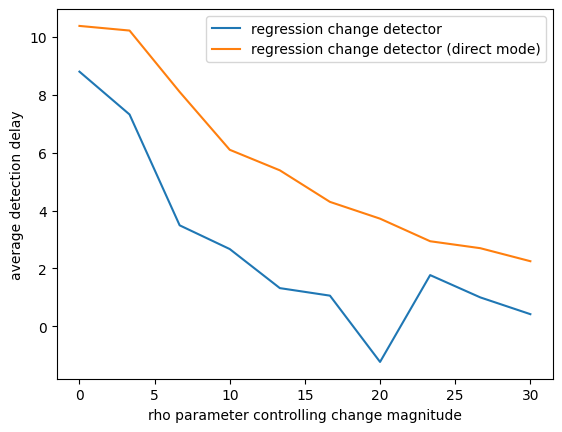

In [11]:
avg_dd1 = np.mean(dd1, axis=1) - changepoint_loc
avg_dd2 = np.mean(dd2, axis=1) - changepoint_loc


plt.plot(rhos, avg_dd1, label="regression change detector")
plt.plot(rhos, avg_dd2, label="regression change detector (direct mode)")
plt.xlabel("rho parameter controlling change magnitude")
plt.ylabel("average detection delay")
plt.legend()
plt.show()

### Make your own detector

In [2]:
@nb.njit
def h(y):
    return y


@nb.njit
def f(sum_pre_j, sum_post_j, g, t):
    res = math.sqrt(1.0 * g / (t * (t - g))) * sum_pre_j
    res = res - math.sqrt(1.0 * (t - g) / t / g) * sum_post_j
    return np.sum(res * res)


@nb.njit
def penalty(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg

    return rr

In [3]:
detector = OnlineChangepointDetector(
    p=1, f=f, h=h, penalty=penalty, penalty_constant=10
)
detector.calibrate_false_alarm(alpha = 0.05, N=1000, K=1000, null_dist=np.random.normal)

In [4]:
# Test the custom detector on a stream with a change in mean
N = 1000
changepoint_loc = 500
K = 1000

prechange_dist = np.random.normal
postchange_dist = np.random.normal
prechange_kwargs = {"loc": 0, "scale": 1, "size": (1,)}
postchange_kwargs = {"loc": 2, "scale": 1, "size": (1,)}

xs = draw_samples(
    K=K, N=N, p=1, seed=42,
    pre_change_dist=prechange_dist, pre_change_kwargs=prechange_kwargs,
    post_change_dist=postchange_dist, post_change_kwargs=postchange_kwargs,
    changepoint_loc=changepoint_loc,
)

pen_const = detector._state["penalty_constant"]
detect_times = np.ones(K, dtype=np.int64) * N
for k in range(K):
    det = OnlineChangepointDetector(
        p=1, f=f, h=h,
        penalty=penalty, penalty_constant=pen_const,
    )
    for i in range(N):
        det.update(xs[k, i])
        if det.alarm:
            detect_times[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times) - changepoint_loc:.1f}")
print(f"Proportion detected: {np.mean(detect_times < N):.3f}")

Average detection delay: 35.3
Proportion detected: 1.000


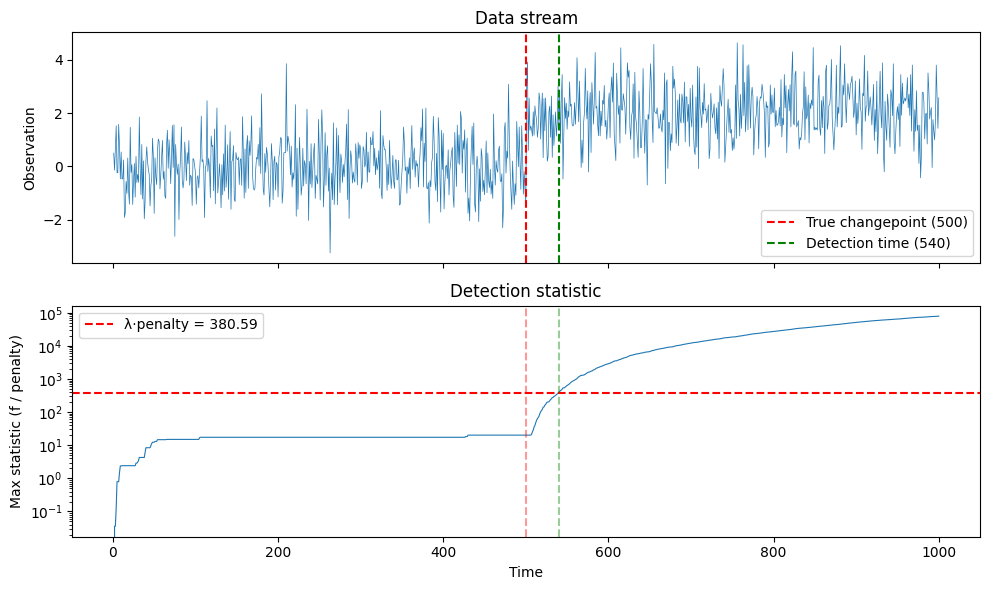

In [5]:
# Run detector on a single stream and record the statistic at each step
single_stream = xs[0]  # pick the first realization
det = OnlineChangepointDetector(
    p=1, f=f, h=h,
    penalty=penalty, penalty_constant=pen_const,
)
stats = np.zeros(N)
alarm_time = None
for i in range(N):
    det.update(single_stream[i])
    stats[i] = det.max_statistic
    if det.alarm and alarm_time is None:
        alarm_time = i + 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Top: raw data stream
ax1.plot(np.arange(1, N + 1), single_stream[:, 0], linewidth=0.5)
ax1.axvline(changepoint_loc, color="red", linestyle="--", label=f"True changepoint ({changepoint_loc})")
if alarm_time is not None:
    ax1.axvline(alarm_time, color="green", linestyle="--", label=f"Detection time ({alarm_time})")
ax1.set_ylabel("Observation")
ax1.legend()
ax1.set_title("Data stream")

# Bottom: test statistic vs threshold (lambda * penalty)
ax2.semilogy(np.arange(1, N + 1), stats, linewidth=0.8)
ax2.axhline(pen_const, color="red", linestyle="--", label=f"λ·penalty = {pen_const:.2f}")
ax2.axvline(changepoint_loc, color="red", linestyle="--", alpha=0.4)
if alarm_time is not None:
    ax2.axvline(alarm_time, color="green", linestyle="--", alpha=0.4)
ax2.set_xlabel("Time")
ax2.set_ylabel("Max statistic (f / penalty)")
ax2.legend()
ax2.set_title("Detection statistic")

plt.tight_layout()
plt.show()

In [2]:
# General LR test — Bernoulli example
# ====================================
# Distribution-specific: user supplies these for each exponential family.
# v = dim(θ) = dim(h(y)) = number of parameters that may change.

V_BERN = 1  # dimension of natural parameter for Bernoulli

@nb.njit
def h_bern(y):
    """Sufficient statistic for Bernoulli: h(y) = y."""
    return y

@nb.njit
def A_bern(theta):
    """Log-partition for Bernoulli: A(θ) = log(1 + exp(θ))."""
    return np.log(1.0 + np.exp(theta)).sum()

@nb.njit
def grad_A_inv_bern(mu):
    """Inverse link (logit) for Bernoulli: θ = log(μ/(1-μ)).
    Gives MLE directly as θ̂ = grad_A_inv(S/n), zero iterations."""
    return np.log(mu / (1.0 - mu))

@nb.njit
def grad_A_bern(theta):
    """Gradient of A for Bernoulli (sigmoid). For Newton fallback."""
    ee = np.exp(theta)
    return ee / (1.0 + ee)

@nb.njit
def hess_A_bern(theta):
    """Hessian of A for Bernoulli. For Newton fallback."""
    ee = np.exp(theta)
    H = np.zeros((1, 1), dtype=np.float64)
    H[0, 0] = (ee / ((1.0 + ee) ** 2)).sum()
    return H

In [3]:
# Generic GLR machinery — works for any exp family once the
# distribution-specific functions above are defined.

EPS = 1e-8  # clamping boundary for MLE

@nb.njit
def loglik_expfam(theta, S, n):
    """Log-likelihood for canonical exp family: θᵀS - n·A(θ)."""
    return np.dot(theta, S) - n * A_bern(theta)

@nb.njit
def closed_form_mle(S, n):
    """MLE via inverse link: θ̂ = (∇A)⁻¹(S/n). O(v), zero iterations."""
    mu = S / n
    for i in range(mu.shape[0]):
        if mu[i] < EPS:
            mu[i] = EPS
        elif mu[i] > 1.0 - EPS:
            mu[i] = 1.0 - EPS
    return grad_A_inv_bern(mu)

@nb.njit
def newton_mle_glr(S, n, theta_init, tol=1e-12, max_iter=100):
    """Safeguarded Newton MLE fallback for families without closed-form inverse.
    Returns (theta_hat, converged)."""
    theta = theta_init.copy()
    v = theta.shape[0]
    ridge = 1e-8
    ll_old = loglik_expfam(theta, S, n)

    for _ in range(max_iter):
        grad = S - n * grad_A_bern(theta)
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta, True

        HA = hess_A_bern(theta)
        H = -n * HA
        for i in range(v):
            H[i, i] -= ridge
        step = np.linalg.solve(H, grad)

        step_scale = 1.0
        for _ in range(6):
            theta_new = theta + step_scale * step
            ll_new = loglik_expfam(theta_new, S, n)
            if np.isfinite(ll_new) and ll_new >= ll_old:
                theta = theta_new
                ll_old = ll_new
                break
            step_scale *= 0.5
        else:
            theta = theta + step_scale * step
            ll_old = loglik_expfam(theta, S, n)

    return theta, False

@nb.njit
def f_glr(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic: LR = ℓ(θ̂₁; seg1) + ℓ(θ̂₂; seg2) - ℓ(θ̂₀; all).
    Uses closed-form MLE (zero iterations).
    pos = changepoint location = number of pre-change observations."""
    n1 = pos        # pre-change segment length
    n2 = t - pos    # post-change segment length
    if n1 < 2 or n2 < 2:
        return 0.0

    S_all = sum_pre_j + sum_post_j
    #theta0 = closed_form_mle(S_all, t)
    #theta1 = closed_form_mle(sum_pre_j, n1)
    #theta2 = closed_form_mle(sum_post_j, n2)

    theta0, conv0 = newton_mle_glr(S_all, t, np.zeros(1))
    theta1, conv1 = newton_mle_glr(sum_pre_j, n1, np.zeros(1))
    theta2, conv2 = newton_mle_glr(sum_post_j, n2, np.zeros(1))

    ll0 = loglik_expfam(theta0, S_all, t)
    ll1 = loglik_expfam(theta1, sum_pre_j, n1)
    ll2 = loglik_expfam(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

@nb.njit
def penalty_glr(g, t, p):
    """Penalty for GLR: √(v·log t) + log t, with v baked in."""
    logt = fastlog(t)
    return math.sqrt(V_BERN * logt) + logt

In [ ]:
# Test the Bernoulli GLR detector
N_test = 200
K_cal = 5000
K_test = 1000
changepoint_loc_glr = N_test // 2

# Create and calibrate under Bernoulli(0.5) null
detector_glr = OnlineChangepointDetector(
    p=1, f=f_glr, h=h_bern, penalty=penalty_glr, penalty_constant=10.0
)
detector_glr.calibrate_false_alarm(
    alpha=0.05, N=N_test, K=K_cal,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
pen_const_glr = detector_glr._state["penalty_constant"]
print(f"Calibrated penalty_constant = {pen_const_glr:.3f}")

# Generate test streams: Bernoulli(0.3) → Bernoulli(0.7)
xs_bern = draw_samples(
    K=K_test, N=N_test, p=1, seed=42,
    pre_change_dist=np.random.binomial,
    pre_change_kwargs={"n": 1, "p": 0.3, "size": (1,)},
    post_change_dist=np.random.binomial,
    post_change_kwargs={"n": 1, "p": 0.7, "size": (1,)},
    changepoint_loc=changepoint_loc_glr,
)

detect_times_glr = np.ones(K_test, dtype=np.int64) * N_test
for k in range(K_test):
    det = OnlineChangepointDetector(
        p=1, f=f_glr, h=h_bern,
        penalty=penalty_glr, penalty_constant=pen_const_glr,
    )
    for i in range(N_test):
        det.update(xs_bern[k, i])
        if det.alarm:
            detect_times_glr[k] = i + 1
            break

print(f"Average detection delay: {np.mean(detect_times_glr) - changepoint_loc_glr:.1f}")
print(f"Proportion detected: {np.mean(detect_times_glr < N_test):.3f}")

Calibrated penalty_constant = 13750510.352


: 

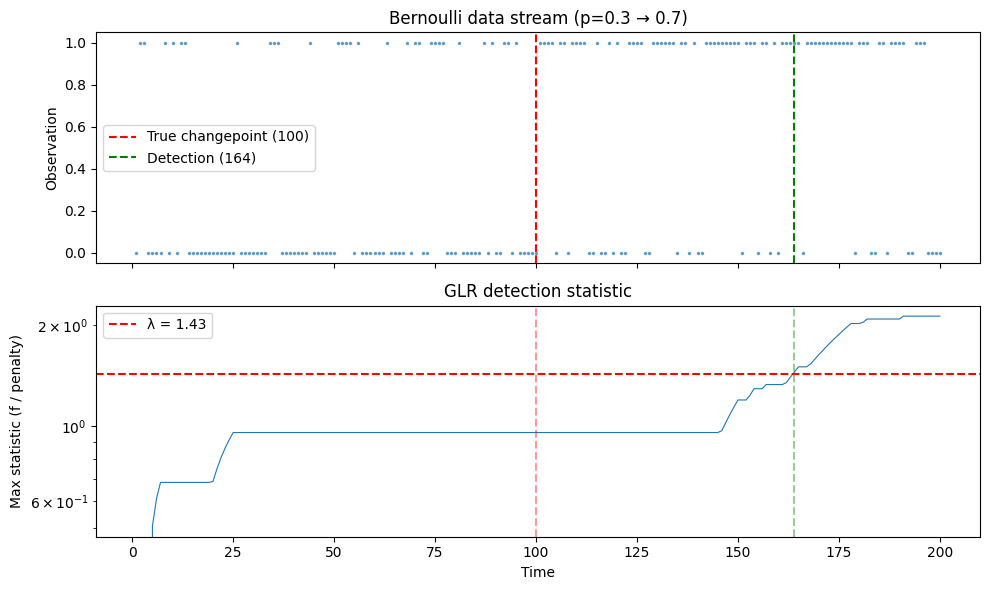

In [53]:
# Visualize a single Bernoulli stream with GLR detector
single_bern = xs_bern[0]
det_viz = OnlineChangepointDetector(
    p=1, f=f_glr, h=h_bern,
    penalty=penalty_glr, penalty_constant=pen_const_glr,
)
stats_glr = np.zeros(N_test)
alarm_time_glr = None
for i in range(N_test):
    det_viz.update(single_bern[i])
    stats_glr[i] = det_viz.max_statistic
    if det_viz.alarm and alarm_time_glr is None:
        alarm_time_glr = i + 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(np.arange(1, N_test + 1), single_bern[:, 0], '.', markersize=3, alpha=0.6)
ax1.axvline(changepoint_loc_glr, color="red", linestyle="--", label=f"True changepoint ({changepoint_loc_glr})")
if alarm_time_glr is not None:
    ax1.axvline(alarm_time_glr, color="green", linestyle="--", label=f"Detection ({alarm_time_glr})")
ax1.set_ylabel("Observation")
ax1.legend()
ax1.set_title("Bernoulli data stream (p=0.3 → 0.7)")

ax2.semilogy(np.arange(1, N_test + 1), stats_glr, linewidth=0.8)
ax2.axhline(pen_const_glr, color="red", linestyle="--", label=f"λ = {pen_const_glr:.2f}")
ax2.axvline(changepoint_loc_glr, color="red", linestyle="--", alpha=0.4)
if alarm_time_glr is not None:
    ax2.axvline(alarm_time_glr, color="green", linestyle="--", alpha=0.4)
ax2.set_xlabel("Time")
ax2.set_ylabel("Max statistic (f / penalty)")
ax2.legend()
ax2.set_title("GLR detection statistic")

plt.tight_layout()
plt.show()

## Gaussian GLR vs built-in CUSUM comparison
Test the exp-family GLR machinery on Gaussian data (change in mean, known variance) and compare to the built-in CUSUM detector. If the two match, the machinery is correct and Bernoulli is just inherently harder.

In [3]:
# Gaussian (known variance σ²=1) exp-family functions
# Natural parameter θ = μ, h(y) = y, A(θ) = θ²/2
# MLE: θ̂ = S/n (sample mean = natural parameter directly)

V_GAUSS = 1

@nb.njit
def h_gauss(y):
    return y

@nb.njit
def A_gauss(theta):
    """Log-partition for N(θ,1): A(θ) = θ²/2."""
    return 0.5 * np.dot(theta, theta)

@nb.njit
def grad_A_gauss(theta):
    """Gradient of A for Gaussian: ∇A(θ) = θ."""
    return theta.copy()

@nb.njit
def hess_A_gauss(theta):
    """Hessian of A for Gaussian: identity matrix."""
    v = theta.shape[0]
    return np.eye(v)

@nb.njit
def grad_A_inv_gauss(mu):
    """Inverse link for Gaussian: identity."""
    return mu.copy()

# --- Closed-form GLR functions for Gaussian ---

@nb.njit
def loglik_gauss(theta, S, n):
    return np.dot(theta, S) - n * A_gauss(theta)

@nb.njit
def closed_form_mle_gauss(S, n):
    return S / n

@nb.njit
def f_glr_gauss(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic for Gaussian using closed-form MLE."""
    n1 = pos
    n2 = t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta0 = closed_form_mle_gauss(S_all, t)
    theta1 = closed_form_mle_gauss(sum_pre_j, n1)
    theta2 = closed_form_mle_gauss(sum_post_j, n2)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

@nb.njit
def penalty_glr_gauss(pos, t, p):
    logt = fastlog(t)
    return math.sqrt(V_GAUSS * logt) + logt

# --- Old array-based Newton (SLOW — for comparison only) ---

@nb.njit
def newton_mle_gauss(S, n, theta_init, tol=1e-12, max_iter=100):
    """Array-based Newton MLE for Gaussian (slow baseline)."""
    theta = theta_init.copy()
    v = theta.shape[0]
    ridge = 1e-8
    ll_old = loglik_gauss(theta, S, n)
    for _ in range(max_iter):
        grad = S - n * grad_A_gauss(theta)
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta
        HA = hess_A_gauss(theta)
        H = -n * HA
        for i in range(v):
            H[i, i] -= ridge
        step = np.linalg.solve(H, grad)
        step_scale = 1.0
        for _ in range(6):
            theta_new = theta + step_scale * step
            ll_new = loglik_gauss(theta_new, S, n)
            if np.isfinite(ll_new) and ll_new >= ll_old:
                theta = theta_new
                ll_old = ll_new
                break
            step_scale *= 0.5
        else:
            theta = theta + step_scale * step
            ll_old = loglik_gauss(theta, S, n)
    return theta

@nb.njit
def f_glr_gauss_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with array-based Newton (slow baseline)."""
    n1 = pos
    n2 = t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta_init = np.zeros(sum_pre_j.shape[0])
    theta0 = newton_mle_gauss(S_all, t, theta_init)
    theta1 = newton_mle_gauss(sum_pre_j, n1, theta0)
    theta2 = newton_mle_gauss(sum_post_j, n2, theta0)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

# =====================================================================
# FAST scalar Newton for v=1 exponential families
# =====================================================================
# User provides scalar functions: A_scalar(theta), A_prime(theta), A_dprime(theta)
# No arrays, no np.linalg.solve, no allocations — just float arithmetic.

# --- Gaussian scalar specializations ---
@nb.njit
def A_scalar_gauss(theta):
    return 0.5 * theta * theta

@nb.njit
def A_prime_gauss(theta):
    return theta

@nb.njit
def A_dprime_gauss(theta):
    return 1.0

# --- Bernoulli scalar specializations ---
@nb.njit
def A_scalar_bern(theta):
    # log(1 + exp(theta)) with overflow protection
    if theta > 30.0:
        return theta
    if theta < -30.0:
        return 0.0
    return math.log(1.0 + math.exp(theta))

@nb.njit
def A_prime_bern(theta):
    # sigmoid
    if theta > 30.0:
        return 1.0
    if theta < -30.0:
        return 0.0
    e = math.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bern(theta):
    # sigmoid * (1 - sigmoid)
    if abs(theta) > 30.0:
        return 0.0
    e = math.exp(theta)
    s = e / (1.0 + e)
    return s * (1.0 - s)

# --- Generic scalar Newton MLE ---
@nb.njit
def scalar_newton_mle(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    """Scalar Newton to solve A'(θ̂) = S/n.
    Returns θ̂ as a float. Pure scalar arithmetic, zero allocations."""
    theta = theta_init
    target = S_scalar / n  # we want A'(θ) = target
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta  # flat region, can't improve
        theta = theta - residual / adp
    return theta

@nb.njit
def scalar_loglik(theta, S_scalar, n, A_scalar):
    """Log-likelihood θ·S - n·A(θ) as a scalar."""
    return theta * S_scalar - n * A_scalar(theta)

# --- Gaussian: scalar Newton f function ---
@nb.njit
def f_glr_gauss_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Gaussian v=1."""
    n1 = pos
    n2 = t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre = sum_pre_j[0]
    s_post = sum_post_j[0]
    s_all = s_pre + s_post

    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_gauss, A_dprime_gauss)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_gauss, A_dprime_gauss)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_gauss, A_dprime_gauss)

    ll0 = scalar_loglik(th0, s_all, t, A_scalar_gauss)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_gauss)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_gauss)
    return ll1 + ll2 - ll0

# --- Bernoulli: scalar Newton f function ---
@nb.njit
def f_glr_bern_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Bernoulli v=1."""
    n1 = pos
    n2 = t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre = sum_pre_j[0]
    s_post = sum_post_j[0]
    s_all = s_pre + s_post

    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_bern, A_dprime_bern)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_bern, A_dprime_bern)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_bern, A_dprime_bern)

    ll0 = scalar_loglik(th0, s_all, t, A_scalar_bern)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_bern)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_bern)
    return ll1 + ll2 - ll0

In [4]:
# Compare: CUSUM vs closed-form GLR vs scalar Newton (all Gaussian)
N_cmp = 200
K_cal_cmp = 5000
K_cmp = 1000
changepoint_cmp = N_cmp // 2

# 1) Closed-form GLR
det_glr_cf = OnlineChangepointDetector(
    p=1, f=f_glr_gauss, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_glr_cf.calibrate_false_alarm(
    alpha=0.05, N=N_cmp, K=K_cal_cmp, null_dist=np.random.normal,
)
pen_glr_cf = det_glr_cf._state["penalty_constant"]

# 2) Scalar Newton GLR (fast)
det_glr_sn = OnlineChangepointDetector(
    p=1, f=f_glr_gauss_scalar_newton, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_glr_sn.calibrate_false_alarm(
    alpha=0.05, N=N_cmp, K=K_cal_cmp, null_dist=np.random.normal,
)
pen_glr_sn = det_glr_sn._state["penalty_constant"]

# 3) Built-in CUSUM
det_cusum = make_univariate_mean_change_detector()
det_cusum.calibrate_false_alarm(
    alpha=0.05, N=N_cmp, K=K_cal_cmp, null_dist=np.random.normal,
)
pen_cusum = det_cusum._state["penalty_constant"]

print(f"Closed-form GLR    λ = {pen_glr_cf:.3f}")
print(f"Scalar Newton GLR  λ = {pen_glr_sn:.3f}")
print(f"Built-in CUSUM     λ = {pen_cusum:.3f}")

# Generate test data: N(0,1) → N(2,1)
xs_gauss = draw_samples(
    K=K_cmp, N=N_cmp, p=1, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": 2, "scale": 1, "size": (1,)},
    changepoint_loc=changepoint_cmp,
)

# --- Run all three and time them ---
dt_cf = np.ones(K_cmp, dtype=np.int64) * N_cmp
dt_sn = np.ones(K_cmp, dtype=np.int64) * N_cmp
dt_cs = np.ones(K_cmp, dtype=np.int64) * N_cmp

# Closed-form GLR
t0 = perf_counter()
for k in range(K_cmp):
    d = OnlineChangepointDetector(
        p=1, f=f_glr_gauss, h=h_gauss,
        penalty=penalty_glr_gauss, penalty_constant=pen_glr_cf,
    )
    for i in range(N_cmp):
        d.update(xs_gauss[k, i])
        if d.alarm:
            dt_cf[k] = i + 1
            break
time_cf = perf_counter() - t0

# Scalar Newton GLR
t0 = perf_counter()
for k in range(K_cmp):
    d = OnlineChangepointDetector(
        p=1, f=f_glr_gauss_scalar_newton, h=h_gauss,
        penalty=penalty_glr_gauss, penalty_constant=pen_glr_sn,
    )
    for i in range(N_cmp):
        d.update(xs_gauss[k, i])
        if d.alarm:
            dt_sn[k] = i + 1
            break
time_sn = perf_counter() - t0

# Built-in CUSUM
t0 = perf_counter()
for k in range(K_cmp):
    d = make_univariate_mean_change_detector(penalty_constant=pen_cusum)
    for i in range(N_cmp):
        d.update(xs_gauss[k, i])
        if d.alarm:
            dt_cs[k] = i + 1
            break
time_cs = perf_counter() - t0

print(f"\n{'Method':<25} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 58)
for name, dt, elapsed in [
    ("Closed-form GLR", dt_cf, time_cf),
    ("Scalar Newton GLR", dt_sn, time_sn),
    ("Built-in CUSUM", dt_cs, time_cs),
]:
    delay = np.mean(dt) - changepoint_cmp
    det_rate = np.mean(dt < N_cmp)
    print(f"{name:<25} {delay:>10.1f} {det_rate:>10.3f} {elapsed:>10.2f}")

Closed-form GLR    λ = 1.410
Scalar Newton GLR  λ = 1.410
Built-in CUSUM     λ = 2.963

Method                     Avg delay   Detected   Time (s)
----------------------------------------------------------
Closed-form GLR                  1.8      1.000       2.82
Scalar Newton GLR                1.8      1.000       2.70
Built-in CUSUM                   3.1      1.000       2.71


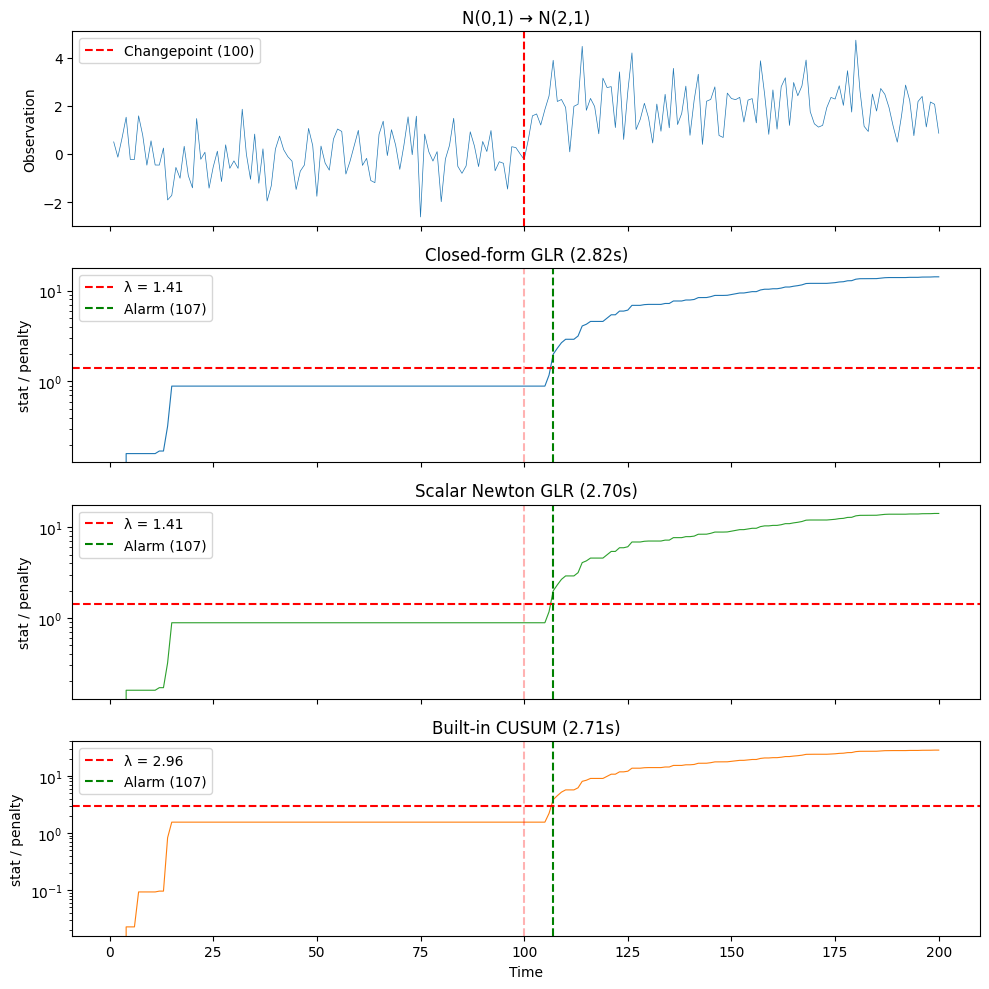

In [5]:
# Visualize all three detectors on a single stream
stream = xs_gauss[0]
d_cf = OnlineChangepointDetector(p=1, f=f_glr_gauss, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=pen_glr_cf)
d_sn = OnlineChangepointDetector(p=1, f=f_glr_gauss_scalar_newton, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=pen_glr_sn)
d_cs = make_univariate_mean_change_detector(penalty_constant=pen_cusum)

s_cf = np.zeros(N_cmp)
s_sn = np.zeros(N_cmp)
s_cs = np.zeros(N_cmp)
a_cf = a_sn = a_cs = None

for i in range(N_cmp):
    d_cf.update(stream[i]); d_sn.update(stream[i]); d_cs.update(stream[i])
    s_cf[i] = d_cf.max_statistic
    s_sn[i] = d_sn.max_statistic
    s_cs[i] = d_cs.max_statistic
    if d_cf.alarm and a_cf is None: a_cf = i + 1
    if d_sn.alarm and a_sn is None: a_sn = i + 1
    if d_cs.alarm and a_cs is None: a_cs = i + 1

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
t_ax = np.arange(1, N_cmp + 1)

axes[0].plot(t_ax, stream[:, 0], linewidth=0.5)
axes[0].axvline(changepoint_cmp, color="red", ls="--", label=f"Changepoint ({changepoint_cmp})")
axes[0].set_ylabel("Observation")
axes[0].legend()
axes[0].set_title("N(0,1) → N(2,1)")

for ax, s, pen, alarm, title, color in [
    (axes[1], s_cf, pen_glr_cf, a_cf, f"Closed-form GLR ({time_cf:.2f}s)", "tab:blue"),
    (axes[2], s_sn, pen_glr_sn, a_sn, f"Scalar Newton GLR ({time_sn:.2f}s)", "tab:green"),
    (axes[3], s_cs, pen_cusum, a_cs, f"Built-in CUSUM ({time_cs:.2f}s)", "tab:orange"),
]:
    ax.semilogy(t_ax, s, linewidth=0.8, color=color)
    ax.axhline(pen, color="red", ls="--", label=f"λ = {pen:.2f}")
    if alarm:
        ax.axvline(alarm, color="green", ls="--", label=f"Alarm ({alarm})")
    ax.axvline(changepoint_cmp, color="red", ls="--", alpha=0.3)
    ax.legend()
    ax.set_ylabel("stat / penalty")
    ax.set_title(title)

axes[3].set_xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
# Average detection delay vs. change-point magnitude for the three methods
phis_cmp = np.linspace(0, 6, 10)
K_sweep = 1000
N_sweep = 200
changepoint_sweep = N_sweep // 2

dd_cf = np.ones((len(phis_cmp), K_sweep)) * N_sweep
dd_sn = np.ones((len(phis_cmp), K_sweep)) * N_sweep
dd_cs = np.ones((len(phis_cmp), K_sweep)) * N_sweep

for j, phi in enumerate(phis_cmp):
    xs_sweep = draw_samples(
        K=K_sweep, N=N_sweep, p=1, seed=1234,
        pre_change_dist=np.random.normal,
        pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
        post_change_dist=np.random.normal,
        post_change_kwargs={"loc": phi, "scale": 1, "size": (1,)},
        changepoint_loc=changepoint_sweep,
    )
    for k in range(K_sweep):
        # Closed-form GLR
        d = OnlineChangepointDetector(
            p=1, f=f_glr_gauss, h=h_gauss,
            penalty=penalty_glr_gauss, penalty_constant=pen_glr_cf,
        )
        for i in range(N_sweep):
            d.update(xs_sweep[k, i])
            if d.alarm:
                dd_cf[j, k] = i + 1
                break

        # Scalar Newton GLR
        d = OnlineChangepointDetector(
            p=1, f=f_glr_gauss_scalar_newton, h=h_gauss,
            penalty=penalty_glr_gauss, penalty_constant=pen_glr_sn,
        )
        for i in range(N_sweep):
            d.update(xs_sweep[k, i])
            if d.alarm:
                dd_sn[j, k] = i + 1
                break

        # Built-in CUSUM
        d = make_univariate_mean_change_detector(penalty_constant=pen_cusum)
        for i in range(N_sweep):
            d.update(xs_sweep[k, i])
            if d.alarm:
                dd_cs[j, k] = i + 1
                break

print("False alarm rates at φ=0:")
print(f"  Closed-form GLR:   {np.mean(dd_cf[0] < N_sweep):.3f}")
print(f"  Scalar Newton GLR: {np.mean(dd_sn[0] < N_sweep):.3f}")
print(f"  Built-in CUSUM:    {np.mean(dd_cs[0] < N_sweep):.3f}")

In [ ]:
avg_dd_cf = np.mean(dd_cf, axis=1) - changepoint_sweep
avg_dd_sn = np.mean(dd_sn, axis=1) - changepoint_sweep
avg_dd_cs = np.mean(dd_cs, axis=1) - changepoint_sweep

plt.figure(figsize=(8, 5))
plt.plot(phis_cmp, avg_dd_cf, "o-", label="Closed-form GLR")
plt.plot(phis_cmp, avg_dd_sn, "s--", label="Scalar Newton GLR")
plt.plot(phis_cmp, avg_dd_cs, "^:", label="Built-in CUSUM")
plt.xlabel("mean change magnitude")
plt.ylabel("average detection delay")
plt.title("Detection delay vs. change-point size (Gaussian, N=200)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Multivariate change in mean or covariance

In [ ]:
@nb.njit
def h_mean_cov(y: np.ndarray) -> np.ndarray:
    p = y.shape[0]
    yy = np.outer(y, y)
    out = np.empty((p + 1, p), dtype=y.dtype)
    out[0] = y
    out[1:] = yy

    return out


@nb.njit
def f_mean_cov(sum_pre_j, sum_post_j, g, t):
    """
    GLR-type statistic for a change in both mean and covariance
    in multivariate Gaussian data.

    sum_pre_j: sum of h(y) over segment 1  (shape (p+1, p))
    sum_post_j: sum of h(y) over segment 2 (shape (p+1, p))
    g: candidate change-point (segment 1 length)
    t: total sample size
    """
    n1 = t - g
    n2 = g

    p = sum_pre_j.shape[0]  # dimension of data
    if n1 <= p or n2 <= p:
        return 0.0

    totalsum = sum_pre_j + sum_post_j
    sum_pre_j_id = sum_pre_j[0]
    sum_post_j_id = sum_post_j[0]
    totalsum_id = totalsum[0]

    sum_pre_j_cov = sum_pre_j[1:]
    sum_post_j_cov = sum_post_j[1:]
    totalsum_cov = totalsum[1:]

    Sigma_tot = (totalsum_cov - np.outer(totalsum_id, totalsum_id) / t) / t
    Sigma_pre_j = (sum_pre_j_cov - np.outer(sum_pre_j_id, sum_pre_j_id) / n1) / n1
    Sigma_post_j = (sum_post_j_cov - np.outer(sum_post_j_id, sum_post_j_id) / n2) / n2

    # GLR statistic: t * log|Sigma| - g* log|Sigma1| - (t-g) * log|Sigma2|
    # Use slogdet for numerical stability
    sign0, logdet0 = np.linalg.slogdet(Sigma_tot)
    sign1, logdet1 = np.linalg.slogdet(Sigma_pre_j)
    sign2, logdet2 = np.linalg.slogdet(Sigma_post_j)

    if False:
        # If any covariance is singular (sign <= 0), treat statistic as 0
        if sign0 <= 0 or sign1 <= 0 or sign2 <= 0:
            if sign0 <= 0:
                print("Sigma_tot is singular or not positive definite")
            if sign1 <= 0:
                print("Sigma_pre_j is singular or not positive definite")
            if sign2 <= 0:
                print("Sigma_post_j is singular or not positive definite")
            return 0.0

    LR = t * logdet0 - n1 * logdet1 - n2 * logdet2
    df = p + (p * (p + 1)) // 2  # Number of parameters in mean+covariance

    return LR - df


@nb.njit
def penalty_mean_cov(g, t, p):
    df = (p * (p + 1)) // 2 + p
    logg = fastlog(t / 0.05)
    rr = math.sqrt(df * logg) + logg

    return rr

In [ ]:
p = 5
S1 = np.zeros((p + 1, p))
S2 = np.zeros((p + 1, p))

T1 = np.zeros((p + 1, p))
T2 = np.zeros((p + 1, p))

NN = 100
for i in range(NN):
    y = np.random.normal(0, 1, p)
    h_y = h_mean_cov(y)
    S1 += h_y
    hy = h_mean_cov(y / 2)
    T1 += hy

    y = np.random.normal(0, 1, p)
    h_y = h_mean_cov(y)
    S2 += h_y
    hy = h_mean_cov(y / 2)
    T2 += hy


r1 = f_mean_cov(S1, S2, 50, 100)
r2 = f_mean_cov(T1, T2, 50, 100)
print(r1)
print(r2)

In [ ]:
N = 1000
K = 1000
p = 10
null_dist = np.random.normal
null_args = (0, 1)  # mean=0, std=1
sample = mc_max_statistics(
    N=N,
    K=K,
    p=p,
    h=h_mean_cov,
    f=f_mean_cov,
    penalty=penalty_mean_cov,
    null_dist=null_dist,
    penalty_constant=0.0,
    null_args=null_args,
    null_kwargs=None,
    auxiliary_data=None,
)

In [ ]:
critical_value = np.percentile(sample, 95)
print(f"Critical value at 95%: {critical_value}")

In [ ]:
xs = np.random.normal(0, 1, (N, p))
xs[(N // 2) :] += 0.4

state = init_state(p, h_mean_cov, f_mean_cov, penalty_mean_cov, critical_value)
for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i+1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

In [ ]:
xs = np.zeros((N, p))
xs[: (N // 2)] = np.random.normal(0, 1, (N // 2, p))
xs[(N // 2) :] = np.random.normal(0, 0.5, (N // 2, p))  # Introduce a changepoint


state = init_state(p, h_mean_cov, f_mean_cov, penalty_mean_cov, critical_value)
for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i+1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

In [ ]:
state

### General likelihood ratio test using Numba, requiring gradients

In [ ]:
## Specific examples are for Bernoulli with natural param theta = log(p/(1-p)) and A(theta) = log(1 + exp(theta))


from matplotlib.pylab import inf


@nb.njit
def h(y):
    return y


@nb.njit
def A_func(theta):
    return np.log(1.0 + np.exp(theta)).sum()


@nb.njit
def grad_A(theta):
    ee = np.exp(theta)
    return ee / (1.0 + ee)


@nb.njit
def hess_A(theta):
    H = np.zeros((1, 1), dtype=np.float64)
    ee = np.exp(theta)
    H[0, 0] = (ee / ((1.0 + ee) ** 2)).sum()
    return H


@nb.njit
def penalty(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg

    return rr


## The below should be general


@nb.njit
def logLik(theta, S, n):
    # S is cumulative sum!
    # n is total sample size

    # if S is numerically zero or n, we return zero:
    if np.all(np.abs(S) < 1e-10) or np.all(np.abs(S - n) < 1e-10):
        return 0.0
    A_theta = A_func(theta)
    return np.dot(theta, S) - n * A_theta


@nb.njit
def newton_mle(
    S, n, theta_init, A_func, grad_A, hess_A, logLik, tol=1e-12, max_iter=1000
):
    """
    Maximize logLik(theta; S, n) = theta @ S - n * A_func(theta)
    over theta ∈ R^v using safeguarded Newton.

    Inputs
    ------
    S : 1D array (v,)
        Sum of sufficient statistics.
    n : int
        Number of observations.
    theta_init : 1D array (v,)
        Starting point (e.g. previous MLE or some fixed value).
    tol : float
        Stop when ||grad||_inf < tol.
    max_iter : int
        Hard cap on number of iterations.

    Returns
    -------
    theta_hat : 1D array (v,)
    converged : boolean
    """

    if (np.abs(S) < 1e-10).all():
        return np.array([-np.inf]), True

    if (np.abs(S - n) < 1e-10).all():
        return np.array([np.inf]), True

    theta = theta_init
    v = theta.shape[0]

    # Small ridge for numerical stability of Hessian
    ridge = 1e-8

    # current log-likelihood
    ll_old = logLik(theta, S, n)

    for it in range(max_iter):
        # Gradient of log-likelihood: S - n * grad_A(theta)
        gA = grad_A(theta)  # shape (v,)
        grad = S - n * gA  # shape (v,)

        # Check convergence: ||grad||_inf < tol
        max_abs_grad = 0.0
        for i in range(v):
            val = grad[i]
            if val < 0.0:
                val = -val
            if val > max_abs_grad:
                max_abs_grad = val
        if max_abs_grad < tol:
            return theta, True

        # Hessian of log-likelihood: H = -n * hess_A(theta)
        HA = hess_A(theta)  # shape (v, v)
        H = np.empty_like(HA)
        for i in range(v):
            for j in range(v):
                H[i, j] = -n * HA[i, j]
        # Add a small ridge to diagonal: H ← H − ridge * I
        # (H is negative semidefinite; we move it slightly more negative
        # to make it better-conditioned)
        for i in range(v):
            H[i, i] = H[i, i] - ridge

        # Solve H * step = grad
        # (instead of explicitly inverting H)
        try:
            step = np.linalg.solve(H, grad)
        except Exception:
            # If solve fails for some reason, abort
            return theta, False

        # Safeguard: start with full Newton step, shrink if ll decreases
        step_scale = 1.0
        theta_new = theta.copy()
        ll_new = ll_old

        # At most a few shrink steps (hard-coded; no user tuning)
        for _ in range(6):
            for i in range(v):
                theta_new[i] = theta[i] + step_scale * step[i]

            ll_candidate = logLik(theta_new, S, n)

            if np.isfinite(ll_candidate) and ll_candidate >= ll_old:
                ll_new = ll_candidate
                break  # accept this step
            else:
                step_scale *= 0.5  # shrink and try again

        # Update
        theta = theta_new
        ll_old = ll_new

    # If we fall out of the loop, we hit max_iter
    return theta, False


@nb.njit
def f(sum_pre_j, sum_post_j, g, t):
    print("###################")
    print("Iter ", t, " g ", g)
    theta_init = np.zeros(sum_pre_j.shape[0], dtype=np.float64)
    theta0, converged = newton_mle(
        sum_pre_j + sum_post_j, t, theta_init, A_func, grad_A, hess_A, logLik
    )
    print("theta0 ", theta0)
    print("converged = ", converged)
    theta1, converged1 = newton_mle(
        sum_pre_j, t - g, theta0, A_func, grad_A, hess_A, logLik
    )
    theta2, converged2 = newton_mle(
        sum_post_j, g, theta0, A_func, grad_A, hess_A, logLik
    )
    print("theta1 ", theta1)
    print("converged1 = ", converged1)
    print("theta2 ", theta2)
    print("converged2 = ", converged2)
    ll0 = logLik(theta0, sum_pre_j + sum_post_j, t)
    ll1 = logLik(theta1, sum_pre_j, t - g)
    ll2 = logLik(theta2, sum_post_j, g)
    print("ll0 = ", ll0)
    print("ll1 = ", ll1)
    print("ll2 = ", ll2)
    print("LR = ", ll1 + ll2 - ll0)
    return ll1 + ll2 - ll0

In [ ]:
p = 1
penalty_constant = 3.0
N = 10
xs = np.zeros(N)
p0 = 0.1
p1 = 0.8
xs[: (N // 2)] = np.random.binomial(n=1, p=p0, size=N // 2)
xs[(N // 2) :] = np.random.binomial(n=1, p=p1, size=N // 2)

xs[:10]

In [ ]:
state = init_state(p, h, f, penalty, penalty_constant)

for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i+1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

### General likelihood ratio test (non-Numba) using autograd. Fully automatic. sucks

In [ ]:
import autograd.numpy as anp
from autograd import grad
from scipy.optimize import minimize

## Currently, the binomial:


def h(y):
    return y


def A_func(theta):
    ## theta is natural parameter, for bernoulli, A(theta) = log(1 + exp(theta))
    ## and theta = log(p/(1-p)) where p is the Bernoulli paramete
    ret = anp.log(1.0 + anp.exp(theta))
    return ret


def logLik(theta, S, n):
    # S is cumulative sum!
    A_theta = A_func(theta)
    return anp.dot(theta, S) - n * A_theta


theta_init = anp.zeros(1)
df = 1
p = 1


def f(sum_pre_j, sum_post_j, g, t):
    # compute MLEs
    # Overall MLE:
    def objective(theta_flat):
        return -logLik(
            theta_flat, sum_pre_j + sum_post_j, t
        )  # negative for minimization

    def objective_grad(theta_flat):
        theta = theta_flat
        gg = grad(logLik, argnum=0)(theta, sum_pre_j + sum_post_j, t)  # shape (v,)
        return -gg  # because we minimize the negative

    res = minimize(
        objective,
        x0=theta_init,
        jac=objective_grad,
        method="L-BFGS-B",
        options={"maxiter": 200, "disp": False},
    )
    theta0 = res.x

    def objective(theta_flat):
        return -logLik(theta_flat, sum_pre_j, t - g)  # negative for minimization

    def objective_grad(theta_flat):
        theta = theta_flat
        gg = grad(logLik, argnum=0)(theta, sum_pre_j, t - g)  # shape (v,)
        return -gg  # because we minimize the negative

    res = minimize(
        objective,
        x0=theta0,
        jac=objective_grad,
        method="L-BFGS-B",
        options={"maxiter": 200, "disp": False},
    )
    theta1 = res.x

    def objective(theta_flat):
        return -logLik(theta_flat, sum_post_j, g)  # negative for minimization

    def objective_grad(theta_flat):
        theta = theta_flat
        gg = grad(logLik, argnum=0)(theta, sum_post_j, g)  # shape (v,)
        return -gg  # because we minimize the negative

    res = minimize(
        objective,
        x0=theta0,
        jac=objective_grad,
        method="L-BFGS-B",
        options={"maxiter": 200, "disp": False},
    )
    theta2 = res.x

    ret = (
        logLik(theta0, sum_pre_j + sum_post_j, t)
        + logLik(theta1, sum_pre_j, t - g)
        + logLik(theta2, sum_post_j, g)
        - df
    )
    print("ret = ", ret)
    return ret


@nb.njit
def penalty(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg

    return rr

In [ ]:
p = 1
penalty_constant = 3.0
N = 100
xs = np.zeros(N)
p0 = 0.5
p1 = 0.8
xs[: (N // 2)] = np.random.binomial(n=1, p=p0, size=N // 2)
xs[(N // 2) :] = np.random.binomial(n=1, p=p1, size=N // 2)

state = init_state(p, h, f, penalty, penalty_constant)
for i in range(N):
    x_new = xs[i]
    update(x_new, state)
    if state["alarm"]:
        print(
            f"Alarm triggered at iteration {i+1} with maxx = {state['maxx']} at position {state['maxpos']}"
        )
        break

In [ ]:
state